### Replicar indicadores de índice de marginación de CONAPO

Para este ejercicio se descargarán los datos a nivel AGEB para poder replicar los indicadores que forman parte del índice de marginación de CONAPO. 

In [1]:
import pandas as pd
import requests
import geopandas as gpd
import os
import numpy as np
from matplotlib import pyplot as plt
import zipfile

In [2]:
#Definir directorio de trabajo
#Directorio de trabajo. Si existe directorio D:/, se selecciona si no, C:/
try:
    os.chdir('C:/users/administracion.sniiv/Documents/GitHub/proyecto_infotec')
except:
    os.chdir('C:/users/claud/Documents/Github/proyecto_infotec')
#if os.path.exists('D:/'):
#    os.chdir('D:/github/proyecto_infotec')
#else:
#    os.chdir('C:/users/claudio.pacheco/Documents/Github/proyecto_infotec')

In [3]:
#crear directorio de salida
if not os.path.exists('datos'):
    os.makedirs('datos')

In [4]:
#Pegar todos los archivos csv en una sola data frame
df=pd.DataFrame()
for entidad in range(1,33):
    if entidad<10:
        df_temp=pd.read_csv("datos/conjunto_de_datos_ageb_urbana_"+"0"+str(entidad)+"_cpv2020.csv",encoding='utf-8', low_memory=False)
    else:
        df_temp=pd.read_csv("datos/conjunto_de_datos_ageb_urbana_"+str(entidad)+"_cpv2020.csv",encoding='utf-8', low_memory=False)
    df=pd.concat([df,df_temp],axis=0)
    print("Se ha agregado la entidad "+str(entidad)," a la dataframe")

#Imprimir el número de registros con separadores de miles
print("Se concluyó la concatenación. El conjunto de datos cuenta con "+str(df.shape[1])+" columnas y "+str("{:,}".format(df.shape[0]))+" registros")
df.columns=df.columns.str.lower()  

Se ha agregado la entidad 1  a la dataframe
Se ha agregado la entidad 2  a la dataframe
Se ha agregado la entidad 3  a la dataframe
Se ha agregado la entidad 4  a la dataframe
Se ha agregado la entidad 5  a la dataframe
Se ha agregado la entidad 6  a la dataframe
Se ha agregado la entidad 7  a la dataframe
Se ha agregado la entidad 8  a la dataframe
Se ha agregado la entidad 9  a la dataframe
Se ha agregado la entidad 10  a la dataframe
Se ha agregado la entidad 11  a la dataframe
Se ha agregado la entidad 12  a la dataframe
Se ha agregado la entidad 13  a la dataframe
Se ha agregado la entidad 14  a la dataframe
Se ha agregado la entidad 15  a la dataframe
Se ha agregado la entidad 16  a la dataframe
Se ha agregado la entidad 17  a la dataframe
Se ha agregado la entidad 18  a la dataframe
Se ha agregado la entidad 19  a la dataframe
Se ha agregado la entidad 20  a la dataframe
Se ha agregado la entidad 21  a la dataframe
Se ha agregado la entidad 22  a la dataframe
Se ha agregado la e

In [5]:
df.columns

Index(['entidad', 'nom_ent', 'mun', 'nom_mun', 'loc', 'nom_loc', 'ageb', 'mza',
       'pobtot', 'pobfem',
       ...
       'vph_telef', 'vph_cel', 'vph_inter', 'vph_stvp', 'vph_spmvpi',
       'vph_cvj', 'vph_sinrtv', 'vph_sinltc', 'vph_sincint', 'vph_sintic'],
      dtype='object', length=230)

In [6]:
#Copia de la base original
df_limpia=df.copy()

In [7]:
#Crear clave geoestadística
df_limpia['cvegeo'] = df_limpia['entidad'].astype(str).str.zfill(2) + df_limpia['mun'].astype(str).str.zfill(3) + df_limpia['loc'].astype(str).str.zfill(4) + df_limpia['ageb'].astype(str).str.zfill(4)
#columnas = ['cvegeo'] + [col for col in df_limpia.columns if col != 'cvegeo']
df_limpia=df_limpia[df_limpia['nom_loc']=='Total AGEB urbana']

df_limpia=df_limpia[['cvegeo','pobtot','tvivparhab','p_6a11','p_12a14','p6a11_noa','p12a14noa','p_15ymas','p15pri_in','p15sec_in','psinder','pder_ss','vph_nodren','vph_excsa','vph_s_elec','vph_aguafv','vph_pisoti','pro_ocup_c','vph_refri','vph_inter','vph_cel','vph_1dor']]
#Transformar a numérico

###Población y vivienda
df_limpia['pobtot']=pd.to_numeric(df_limpia['pobtot'], errors='coerce')
df_limpia['tvivparhab']=pd.to_numeric(df_limpia['tvivparhab'], errors='coerce')


###Datos para población de 6 a 14 años que no asiste a la escuela
df_limpia['p_6a11']=pd.to_numeric(df_limpia['p_6a11'], errors='coerce')
df_limpia['p_12a14']=pd.to_numeric(df_limpia['p_12a14'], errors='coerce')
df_limpia['p6a11_noa']=pd.to_numeric(df_limpia['p6a11_noa'], errors='coerce')
df_limpia['p12a14noa']=pd.to_numeric(df_limpia['p12a14noa'], errors='coerce')


##Datos para población de 15 años o más sin educación básica
df_limpia['p_15ymas']=pd.to_numeric(df_limpia['p_15ymas'], errors='coerce')
df_limpia['p15pri_in']=pd.to_numeric(df_limpia['p15pri_in'], errors='coerce')
df_limpia['p15sec_in']=pd.to_numeric(df_limpia['p15sec_in'], errors='coerce')


#Datos para población sin derechohabiencia
df_limpia['psinder']=pd.to_numeric(df_limpia['psinder'], errors='coerce')
df_limpia['pder_ss']=pd.to_numeric(df_limpia['pder_ss'], errors='coerce')

#Datos para ocupantes sin drenaje ni sanitario
df_limpia['vph_nodren']=pd.to_numeric(df_limpia['vph_nodren'], errors='coerce')
df_limpia['vph_excsa']=pd.to_numeric(df_limpia['vph_excsa'], errors='coerce')


#Datos para ocupantes sin energía eléctrica
df_limpia['vph_s_elec']=pd.to_numeric(df_limpia['vph_s_elec'],errors='coerce')

#Datos para ocupantes sin agua entubada
df_limpia['vph_aguafv']=pd.to_numeric(df_limpia['vph_aguafv'], errors='coerce')

#Datos para ocupantes con piso de tierra
df_limpia['vph_pisoti']=pd.to_numeric(df_limpia['vph_pisoti'], errors='coerce')


##Datos para ocupantes en hacinamiento
df_limpia['pro_ocup_c']=pd.to_numeric(df_limpia['pro_ocup_c'], errors='coerce')
df_limpia['cuartos']=df_limpia['pro_ocup_c']*df_limpia['pobtot']
df_limpia['vph_1dor']=pd.to_numeric(df_limpia['vph_1dor'], errors='coerce')


#Datos para ocupantes sin refrigerador
df_limpia['vph_refri']=pd.to_numeric(df_limpia['vph_refri'], errors='coerce')


#Datos para ocupantes sin internet
df_limpia['vph_inter']=pd.to_numeric(df_limpia['vph_inter'], errors='coerce')

#Datos para ocupantes sin celular
df_limpia['vph_cel']=pd.to_numeric(df_limpia['vph_cel'], errors='coerce')


#renombrar pobtot a pobcenso
df_limpia=df_limpia.rename(columns={'pobtot':'pobcenso'})
df_limpia

,cvegeo,pobcenso,tvivparhab,p_6a11,p_12a14,p6a11_noa,p12a14noa,p_15ymas,p15pri_in,p15sec_in,...,vph_excsa,vph_s_elec,vph_aguafv,vph_pisoti,pro_ocup_c,vph_refri,vph_inter,vph_cel,vph_1dor,cuartos
3,0100100010017,2237,648.0,271.0,119.0,29.0,22.0,1460.0,61.0,93.0,...,648.0,3.0,0.0,NaN,1.14,514.0,189.0,625.0,192.0,2550.18
25,010010001006A,1411,400.0,145.0,105.0,NaN,NaN,1057.0,10.0,22.0,...,400.0,0.0,0.0,0.0,0.65,400.0,388.0,397.0,64.0,917.15
53,0100100010106,2962,1030.0,342.0,135.0,11.0,4.0,2103.0,14.0,16.0,...,1029.0,0.0,0.0,NaN,0.72,1025.0,826.0,1021.0,261.0,2132.64
106,0100100010163,2698,790.0,401.0,102.0,10.0,4.0,1666.0,19.0,31.0,...,790.0,0.0,0.0,NaN,0.98,775.0,524.0,783.0,148.0,2644.04
141,0100100010182,2218,663.0,231.0,110.0,4.0,NaN,1764.0,7.0,17.0,...,663.0,0.0,0.0,NaN,0.59,659.0,645.0,660.0,86.0,1308.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33812,3205800010087,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33814,3205800010091,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00
33816,3205800010104,169,45.0,19.0,19.0,0.0,NaN,101.0,9.0,NaN,...,45.0,0.0,0.0,0.0,1.30,38.0,9.0,43.0,23.0,219.70
33819,3205800010119,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
colonias=gpd.read_file('C:/Users/claud/Documents/GitHub/proyecto_simi/data/colonias_imc2020.shp')
colonias.columns=colonias.columns.str.lower()
colonias

,objectid,cve_col,id_col,colonia,cp,cve_ent,nom_ent,mun,cve_mun,nom_mun,...,ovpt,ovhac,ovsref,ovsint,ovscel,im_2020,gm_2020,imn_2020,clasif,geometry
0,1,01001_0001,1,14 Ava,20170,01,Aguascalientes,001,01001,Aguascalientes,...,0.058815,20.913198,0.381530,26.904485,0.531057,154.634613,Muy bajo,0.985889,Zona militar,"POLYGON ((2473175.554 1098535.431, 2473170.862..."
1,2,01001_0002,2,2 de Octubre,20367,01,Aguascalientes,001,01001,Aguascalientes,...,5.868434,41.930905,15.097019,75.911029,7.051585,145.999976,Alto,0.930838,Colonia,"POLYGON ((2478466.122 1097323.635, 2478365.765..."
2,3,01001_0003,3,Agricultura,20234,01,Aguascalientes,001,01001,Aguascalientes,...,0.079539,2.276789,0.265865,12.328814,2.316559,152.595148,Muy bajo,0.972886,Fraccionamiento,"POLYGON ((2469627.868 1093884.449, 2469377.552..."
3,4,01001_0004,4,Agua Clara,20263,01,Aguascalientes,001,01001,Aguascalientes,...,0.349345,13.071323,1.455606,20.931591,2.852986,153.648279,Muy bajo,0.979600,Fraccionamiento,"POLYGON ((2474240.666 1093895.661, 2474151.885..."
4,5,01001_0005,5,Alameda,20164,01,Aguascalientes,001,01001,Aguascalientes,...,0.719920,9.576962,2.164748,16.221925,3.509944,153.133948,Muy bajo,0.976321,Fraccionamiento,"POLYGON ((2472360.905 1097265.814, 2472307.472..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74221,105634,30206_0033,105634,El Rodeo,93770,30,Veracruz de Ignacio de la Llave,206,30206,Nanchital de Lázaro Cárdenas del Río,...,9.106453,42.443519,10.871395,79.247643,6.955211,142.740814,Muy alto,0.910058,Colonia,"POLYGON ((3303277.788 695215.083, 3303258.815 ..."
74222,105639,32007_0010,105639,La Estrella,98200,32,Zacatecas,007,32007,Concepción del Oro,...,0.561798,24.227529,3.581461,39.255618,5.126404,152.076766,Bajo,0.969581,Colonia,"POLYGON ((2557923.757 1397970.118, 2558119.162..."
74223,105640,32009_0015,105640,Cardenillo,99260,32,Zacatecas,009,32009,Chalchihuites,...,0.952381,17.278911,4.353741,43.673468,8.299320,148.592141,Medio,0.947364,Barrio,"POLYGON ((2308442.943 1273426.128, 2308519.682..."
74224,105647,32010_0137,105647,Los Tanques,99099,32,Zacatecas,010,32010,Fresnillo,...,0.548697,17.695474,3.017833,32.373114,0.823045,153.102103,Muy bajo,0.976118,Colonia,"POLYGON ((2412983.859 1237575.286, 2412980.728..."


In [9]:
agebs=gpd.read_file('C:/Users/claud/Downloads/mg_2020_integrado/conjunto_de_datos/00a.shp')
agebs.columns=agebs.columns.str.lower()

In [10]:
agebs_t=agebs.merge(df_limpia, on='cvegeo', how='left')
agebs_t['area_origen'] = agebs_t['geometry'].area

In [11]:
interseccion = gpd.overlay(agebs_t, colonias, how='intersection', keep_geom_type=False)
interseccion['area_interseccion'] = interseccion['geometry'].area
interseccion['proporcion_area'] = interseccion['area_interseccion'] / interseccion['area_origen']
#Variables ponderadas

#Población y vivienda
interseccion['pobpondera'] = interseccion['pobcenso'] * interseccion['proporcion_area']
interseccion['vivpondera'] = interseccion['tvivparhab'] * interseccion['proporcion_area']
#Población de 6 a 14 años que no asiste a la escuela
interseccion['p_6a11_pondera'] = interseccion['p_6a11'] * interseccion['proporcion_area']
interseccion['p_12a14_pondera'] = interseccion['p_12a14'] * interseccion['proporcion_area']
interseccion['p6a11_noa_pondera'] = interseccion['p6a11_noa'] * interseccion['proporcion_area']
interseccion['p12a14_noa_pondera'] = interseccion['p12a14noa'] * interseccion['proporcion_area']

#Población de 15 años o más sin educación básica
interseccion['p_15ymas_pondera'] = interseccion['p_15ymas'] * interseccion['proporcion_area']
interseccion['p15pri_in_pondera'] = interseccion['p15pri_in'] * interseccion['proporcion_area']
interseccion['p15sec_in_pondera'] = interseccion['p15sec_in'] * interseccion['proporcion_area']

#Población sin derechohabiencia
interseccion['psinder_pondera'] = interseccion['psinder'] * interseccion['proporcion_area']
interseccion['pder_pondera'] = interseccion['pder_ss'] * interseccion['proporcion_area']

#Ocupantes sin drenaje ni sanitario
interseccion['vph_nodren_pondera'] = interseccion['vph_nodren'] * interseccion['proporcion_area']
interseccion['vph_excsa_pondera'] = interseccion['vph_excsa'] * interseccion['proporcion_area']

#Ocupantes sin energía eléctrica
interseccion['vph_s_elec_pondera'] = interseccion['vph_s_elec'] * interseccion['proporcion_area']

#Ocupantes con piso de tierra
interseccion['vph_pisoti_pondera'] = interseccion['vph_pisoti'] * interseccion['proporcion_area']

#Ocupantes en hacinamiento
interseccion['cuartos_pondera'] = interseccion['cuartos'] * interseccion['proporcion_area']
interseccion['vph_1dor_pondera'] = interseccion['vph_1dor'] * interseccion['proporcion_area']

#Ocupantes sin refrigerador
interseccion['vph_refri_pondera'] = interseccion['vph_refri'] * interseccion['proporcion_area']

#Ocupantes sin internet
interseccion['vph_inter_pondera'] = interseccion['vph_inter'] * interseccion['proporcion_area']

#Ocupantes sin celular
interseccion['vph_cel_pondera'] = interseccion['vph_cel'] * interseccion['proporcion_area']

#Ocupantes sin agua entubada
interseccion['vph_aguafv_pondera'] = interseccion['vph_aguafv'] * interseccion['proporcion_area']

interseccion

,cvegeo,cve_ent_1,cve_mun_1,cve_loc_1,cve_ageb,ambito,pobcenso,tvivparhab,p_6a11,p_12a14,...,vph_nodren_pondera,vph_excsa_pondera,vph_s_elec_pondera,vph_pisoti_pondera,cuartos_pondera,vph_1dor_pondera,vph_refri_pondera,vph_inter_pondera,vph_cel_pondera,vph_aguafv_pondera
0,010060001009A,01,006,0001,009A,Urbana,2940.0,725.0,314.0,140.0,...,0.0,345.114869,1.433995,3.345989,1194.518087,64.051790,328.862923,229.439248,294.925034,0.0
1,010060001009A,01,006,0001,009A,Urbana,2940.0,725.0,314.0,140.0,...,0.0,6.351111,0.026390,0.061576,21.982586,1.178738,6.052029,4.222345,5.427473,0.0
2,010060001009A,01,006,0001,009A,Urbana,2940.0,725.0,314.0,140.0,...,0.0,215.947459,0.897289,2.093673,747.441414,40.078891,205.778188,143.566178,184.542358,0.0
3,010060001009A,01,006,0001,009A,Urbana,2940.0,725.0,314.0,140.0,...,0.0,0.179741,0.000747,0.001743,0.622123,0.033359,0.171277,0.119495,0.153601,0.0
4,010060001009A,01,006,0001,009A,Urbana,2940.0,725.0,314.0,140.0,...,0.0,0.081689,0.000339,0.000792,0.282743,0.015161,0.077842,0.054308,0.069809,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280873,320570145,32,057,0000,0145,Rural,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
280874,320570145,32,057,0000,0145,Rural,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
280875,32057015A,32,057,0000,015A,Rural,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
280876,320580049,32,058,0000,0049,Rural,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
agrupa=interseccion.groupby(['cve_ent_1','cve_mun_1','nom_ent','nom_mun','cve_col','colonia']).agg({'pobpondera':'sum','vivpondera':'sum','p_6a11_pondera':'sum','p_12a14_pondera':'sum','p6a11_noa_pondera':'sum','p12a14_noa_pondera':'sum','p_15ymas_pondera':'sum','p15pri_in_pondera':'sum','p15sec_in_pondera':'sum','psinder_pondera':'sum','pder_pondera':'sum','vph_nodren_pondera':'sum','vph_excsa_pondera':'sum','vph_s_elec_pondera':'sum','vph_pisoti_pondera':'sum','cuartos_pondera':'sum','vph_refri_pondera':'sum','vph_inter_pondera':'sum','vph_cel_pondera':'sum','vph_aguafv_pondera':'sum','vph_1dor_pondera':'sum'}).reset_index()
#Dejar la primera coincidencia de cve_col
agrupa=agrupa.drop_duplicates(subset=['cve_col'])
print(len(agrupa))
agrupa["prom_ocup_pondera"] = agrupa['pobpondera'] / agrupa['vivpondera']

74226


In [13]:
#Calcular indicadores

#Población de 6 a 14 años que no asiste a la escuela
agrupa['indica1'] = ((agrupa['p6a11_noa_pondera'] + agrupa['p12a14_noa_pondera']) / (agrupa['p_6a11_pondera']+agrupa['p_12a14_pondera']))*100

#Población de 15 años o más sin educación básica
agrupa['indica2'] = ((agrupa['p15pri_in_pondera'] + agrupa['p15sec_in_pondera']) / agrupa['p_15ymas_pondera'])*100

#Población sin derechohabiencia
agrupa['indica3'] = (agrupa['psinder_pondera'] / agrupa['pobpondera'])*100

#Ocupantes sin drenaje ni sanitario
agrupa['indica4'] = (agrupa['prom_ocup_pondera']*(agrupa['vph_nodren_pondera'] + (agrupa['vivpondera']-agrupa['vph_excsa_pondera'])) / agrupa['pobpondera'])*100

#Ocupantes sin energía eléctrica
agrupa['indica5'] = ((agrupa['prom_ocup_pondera'] * agrupa['vph_s_elec_pondera']) / agrupa['pobpondera'])*100

#Ocupantes sin agua entubada
agrupa['indica6'] = ((agrupa['prom_ocup_pondera'] * agrupa['vph_aguafv_pondera']) / agrupa['pobpondera'])*100

#Ocupantes con piso de tierra
agrupa['indica7'] = ((agrupa['prom_ocup_pondera'] * agrupa['vph_pisoti_pondera']) / agrupa['pobpondera'])*100

#Ocupantes en hacinamiento
#agrupa['indica8'] = (agrupa['pobpondera'] / agrupa['cuartos_pondera'])*100
agrupa['indica8'] = ((agrupa['prom_ocup_pondera'] * agrupa['vph_1dor_pondera']) / agrupa['pobpondera'])*100


#Ocupantes sin refrigerador
agrupa['indica9'] = ((agrupa['prom_ocup_pondera'] * (agrupa['vivpondera'] - agrupa['vph_refri_pondera'])) / agrupa['pobpondera'])*100

#Ocupantes sin internet
agrupa['indica10'] = ((agrupa['prom_ocup_pondera'] * (agrupa['vivpondera'] - agrupa['vph_inter_pondera'])) / agrupa['pobpondera'])*100

#Ocupantes sin celular
agrupa['indica11'] = ((agrupa['prom_ocup_pondera'] * (agrupa['vivpondera'] - agrupa['vph_cel_pondera'])) / agrupa['pobpondera'])*100

In [14]:
agrupa

,cve_ent_1,cve_mun_1,nom_ent,nom_mun,cve_col,colonia,pobpondera,vivpondera,p_6a11_pondera,p_12a14_pondera,...,indica2,indica3,indica4,indica5,indica6,indica7,indica8,indica9,indica10,indica11
0,01,001,Aguascalientes,Aguascalientes,01001_0001,14 Ava,309.370535,71.754648,61.817618,25.024995,...,0.934449,3.498438,0.005577,0.002536,0.000000,8.179656e-02,10.059785,0.580440,25.469542,0.702971
1,01,001,Aguascalientes,Aguascalientes,01001_0002,2 de Octubre,506.443335,110.583392,61.249853,29.790784,...,20.181564,22.635294,7.543103,0.000000,3.017241,5.172414e+00,30.818966,14.870690,78.232759,8.836207
2,01,001,Aguascalientes,Aguascalientes,01001_0003,Agricultura,352.361795,117.958235,20.269867,9.974243,...,3.352441,23.799786,1.089814,0.000000,0.000000,0.000000e+00,21.041357,1.751027,16.326731,4.399102
3,01,001,Aguascalientes,Aguascalientes,01001_0004,Agua Clara,492.042366,133.932938,40.251508,22.346023,...,4.351036,8.267850,0.000000,0.000000,0.000000,9.363878e-07,13.368987,1.604281,23.208565,4.064172
4,01,001,Aguascalientes,Aguascalientes,01001_0005,Alameda,107.643719,30.263953,9.767139,5.753526,...,4.993795,16.796741,0.087976,0.299109,0.224331,8.225484e-01,14.849978,2.062980,15.808863,4.038001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79769,32,057,Zacatecas,Trancoso,32057_0016,Trancosito,652.864696,145.687383,91.537558,34.030815,...,16.737423,13.467829,3.660668,1.461635,2.948473,1.833351e+00,18.504308,6.718010,73.964706,10.733130
79770,32,058,Zacatecas,Santa María de la Paz,32058_0001,El Rosario,54.918472,14.628231,6.176440,6.163644,...,8.951060,17.174193,0.003124,0.000000,0.000000,4.686046e-03,51.055920,15.529522,79.926585,4.487660
79771,32,058,Zacatecas,Santa María de la Paz,32058_0002,Los Mezquites,51.089052,15.174966,6.431295,2.384638,...,20.275591,22.065064,0.952381,0.000000,0.000000,1.428571e+00,34.285714,7.619048,57.619048,17.619048
79772,32,058,Zacatecas,Santa María de la Paz,32058_0003,Nueva Santa Maria,221.157757,62.285246,25.275172,8.124163,...,23.163842,5.306122,0.000000,0.000000,0.000000,0.000000e+00,33.333333,7.246377,78.260870,5.797101


### Generar índice de marginación

In [15]:
#1 Multiplicar los indicadores por -1

indicadores=['indica1','indica2','indica3','indica4','indica5','indica6','indica7','indica8','indica9','indica10','indica11']
agrupa[indicadores] = agrupa[indicadores]*-1


In [16]:
#Crear vector de referencia (mínimo de cada indicador)
vector_referencia = agrupa[indicadores].min()

In [17]:
#Calcular la distancia dp2

def calcular_dp2(fila,referencia):
    distancia=np.sqrt(((fila-referencia)**2).sum())
    return distancia

In [18]:
agrupa['dp2'] = agrupa[indicadores].apply(calcular_dp2,referencia=vector_referencia,axis=1)

In [19]:
#Normalizar la distancia dp2
dp2_min = agrupa['dp2'].min()
dp2_max = agrupa['dp2'].max()
agrupa['imn'] = (agrupa['dp2']-dp2_min)/(dp2_max-dp2_min)

In [20]:
agrupa

,cve_ent_1,cve_mun_1,nom_ent,nom_mun,cve_col,colonia,pobpondera,vivpondera,p_6a11_pondera,p_12a14_pondera,...,indica4,indica5,indica6,indica7,indica8,indica9,indica10,indica11,dp2,imn
0,01,001,Aguascalientes,Aguascalientes,01001_0001,14 Ava,309.370535,71.754648,61.817618,25.024995,...,-0.005577,-0.002536,-0.000000,-8.179656e-02,-10.059785,-0.580440,-25.469542,-0.702971,341.363480,0.971712
1,01,001,Aguascalientes,Aguascalientes,01001_0002,2 de Octubre,506.443335,110.583392,61.249853,29.790784,...,-7.543103,-0.000000,-3.017241,-5.172414e+00,-30.818966,-14.870690,-78.232759,-8.836207,307.646021,0.875733
2,01,001,Aguascalientes,Aguascalientes,01001_0003,Agricultura,352.361795,117.958235,20.269867,9.974243,...,-1.089814,-0.000000,-0.000000,-0.000000e+00,-21.041357,-1.751027,-16.326731,-4.399102,332.900313,0.947621
3,01,001,Aguascalientes,Aguascalientes,01001_0004,Agua Clara,492.042366,133.932938,40.251508,22.346023,...,-0.000000,-0.000000,-0.000000,-9.363878e-07,-13.368987,-1.604281,-23.208565,-4.064172,337.565408,0.960900
4,01,001,Aguascalientes,Aguascalientes,01001_0005,Alameda,107.643719,30.263953,9.767139,5.753526,...,-0.087976,-0.299109,-0.224331,-8.225484e-01,-14.849978,-2.062980,-15.808863,-4.038001,336.476161,0.957799
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79769,32,057,Zacatecas,Trancoso,32057_0016,Trancosito,652.864696,145.687383,91.537558,34.030815,...,-3.660668,-1.461635,-2.948473,-1.833351e+00,-18.504308,-6.718010,-73.964706,-10.733130,317.709615,0.904379
79770,32,058,Zacatecas,Santa María de la Paz,32058_0001,El Rosario,54.918472,14.628231,6.176440,6.163644,...,-0.003124,-0.000000,-0.000000,-4.686046e-03,-51.055920,-15.529522,-79.926585,-4.487660,315.926252,0.899303
79771,32,058,Zacatecas,Santa María de la Paz,32058_0002,Los Mezquites,51.089052,15.174966,6.431295,2.384638,...,-0.952381,-0.000000,-0.000000,-1.428571e+00,-34.285714,-7.619048,-57.619048,-17.619048,314.671914,0.895732
79772,32,058,Zacatecas,Santa María de la Paz,32058_0003,Nueva Santa Maria,221.157757,62.285246,25.275172,8.124163,...,-0.000000,-0.000000,-0.000000,-0.000000e+00,-33.333333,-7.246377,-78.260870,-5.797101,322.269299,0.917359


(0.0, 1.0)

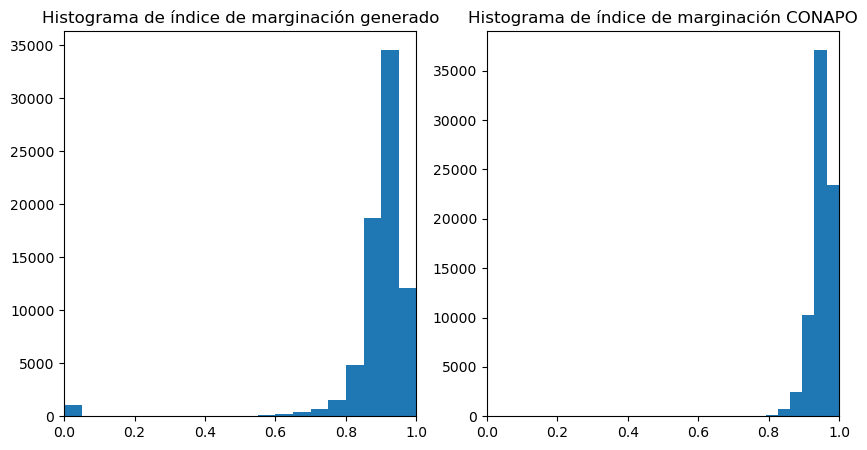

In [21]:
#Histogramas de colonias y de agrupa
fig, ax=plt.subplots(1,2,figsize=(10,5))
ax[0].hist(agrupa['imn'],bins=20)
ax[1].hist(colonias['imn_2020'],bins=20)
ax[0].set_title('Histograma de índice de marginación generado')
ax[1].set_title('Histograma de índice de marginación CONAPO')
#x lim de 0 a 1
ax[0].set_xlim(0,1)
ax[1].set_xlim(0,1)

### Utilizar datos 2010

In [22]:
# URL base y configuración
url_basica = "https://www.inegi.org.mx/contenidos/programas/ccpv/2010/datosabiertos/ageb_y_manzana/resageburb_"
fin = "_2010_csv.zip"
path = r"C:/Users/claud/Documents/GitHub/proyecto_simi/data/datos_2010_tot/"

In [23]:
# Descargar y descomprimir archivos para todas las entidades
for entidad in range(1, 33):
    # Formato de la entidad (dos dígitos)
    entidad_str = f"{entidad:02}"
    url = f"{url_basica}{entidad_str}{fin}"
    zip_path = os.path.join(path, f"entidad_{entidad_str}.zip")
    
    try:
        # Descargar el archivo ZIP
        response = requests.get(url)
        response.raise_for_status()  # Lanza excepción si hay un error en la solicitud
        
        # Guardar el archivo ZIP
        with open(zip_path, 'wb') as file:
            file.write(response.content)
        
        print(f"Se ha descargado el archivo ZIP de la entidad {entidad_str} correctamente.")
        
        # Descomprimir el archivo ZIP
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(os.path.join(path, f"entidad_{entidad_str}"))
        
        print(f"El archivo ZIP de la entidad {entidad_str} se ha descomprimido correctamente.")
        
        # Opcional: eliminar el archivo ZIP después de la descompresión
        os.remove(zip_path)

    except requests.exceptions.RequestException as e:
        print(f"Error al descargar el archivo ZIP de la entidad {entidad_str}: {e}")
    except zipfile.BadZipFile as e:
        print(f"Error al descomprimir el archivo ZIP de la entidad {entidad_str}: {e}")

Se ha descargado el archivo ZIP de la entidad 01 correctamente.
El archivo ZIP de la entidad 01 se ha descomprimido correctamente.
Se ha descargado el archivo ZIP de la entidad 02 correctamente.
El archivo ZIP de la entidad 02 se ha descomprimido correctamente.
Se ha descargado el archivo ZIP de la entidad 03 correctamente.
El archivo ZIP de la entidad 03 se ha descomprimido correctamente.
Se ha descargado el archivo ZIP de la entidad 04 correctamente.
El archivo ZIP de la entidad 04 se ha descomprimido correctamente.
Se ha descargado el archivo ZIP de la entidad 05 correctamente.
El archivo ZIP de la entidad 05 se ha descomprimido correctamente.
Se ha descargado el archivo ZIP de la entidad 06 correctamente.
El archivo ZIP de la entidad 06 se ha descomprimido correctamente.
Se ha descargado el archivo ZIP de la entidad 07 correctamente.
El archivo ZIP de la entidad 07 se ha descomprimido correctamente.
Se ha descargado el archivo ZIP de la entidad 08 correctamente.
El archivo ZIP de l

In [24]:
#Pegar todos los archivos csv en una sola data frame
df_2010=pd.DataFrame()
for entidad in range(1,33):
    if entidad<10:
        df_temp=pd.read_csv("C:/Users/claud/Documents/GitHub/proyecto_simi/data/datos_2010_tot/entidad_0"+str(entidad)+"/resultados_ageb_urbana_0"+str(entidad)+"_cpv2010/conjunto_de_datos/resultados_ageb_urbana_0"+str(entidad)+"_cpv2010.csv",encoding='utf-8', low_memory=False)
    else:
        df_temp=pd.read_csv("C:/Users/claud/Documents/GitHub/proyecto_simi/data/datos_2010_tot/entidad_"+str(entidad)+"/resultados_ageb_urbana_"+str(entidad)+"_cpv2010/conjunto_de_datos/resultados_ageb_urbana_"+str(entidad)+"_cpv2010.csv",encoding='utf-8', low_memory=False)
        
    df_2010=pd.concat([df_2010,df_temp],axis=0)
    
    print("Se ha agregado la entidad "+str(entidad)," a la dataframe")
#Imprimir el número de registros con separadores de miles
print("Se concluyó la concatenación. El conjunto de datos cuenta con "+str(df_2010.shape[1])+" columnas y "+str("{:,}".format(df_2010.shape[0]))+" registros")
df_2010.columns=df_2010.columns.str.lower()


Se ha agregado la entidad 1  a la dataframe
Se ha agregado la entidad 2  a la dataframe
Se ha agregado la entidad 3  a la dataframe
Se ha agregado la entidad 4  a la dataframe
Se ha agregado la entidad 5  a la dataframe
Se ha agregado la entidad 6  a la dataframe
Se ha agregado la entidad 7  a la dataframe
Se ha agregado la entidad 8  a la dataframe
Se ha agregado la entidad 9  a la dataframe
Se ha agregado la entidad 10  a la dataframe
Se ha agregado la entidad 11  a la dataframe
Se ha agregado la entidad 12  a la dataframe
Se ha agregado la entidad 13  a la dataframe
Se ha agregado la entidad 14  a la dataframe
Se ha agregado la entidad 15  a la dataframe
Se ha agregado la entidad 16  a la dataframe
Se ha agregado la entidad 17  a la dataframe
Se ha agregado la entidad 18  a la dataframe
Se ha agregado la entidad 19  a la dataframe
Se ha agregado la entidad 20  a la dataframe
Se ha agregado la entidad 21  a la dataframe
Se ha agregado la entidad 22  a la dataframe
Se ha agregado la e

In [25]:
df_2010.columns

Index(['entidad', 'nom_ent', 'mun', 'nom_mun', 'loc', 'nom_loc', 'ageb', 'mza',
       'pobtot', 'pobmas',
       ...
       'vph_snbien', 'vph_radio', 'vph_tv', 'vph_refri', 'vph_lavad',
       'vph_autom', 'vph_pc', 'vph_telef', 'vph_cel', 'vph_inter'],
      dtype='object', length=198)

In [26]:
df_limpia_2010=df_2010.copy()

In [27]:
#Crear clave geoestadística
df_limpia_2010['cvegeo'] = df_limpia_2010['entidad'].astype(str).str.zfill(2) + df_limpia_2010['mun'].astype(str).str.zfill(3) + df_limpia_2010['loc'].astype(str).str.zfill(4) + df_limpia_2010['ageb'].astype(str).str.zfill(4)
df_limpia_2010=df_limpia_2010[df_limpia_2010['nom_loc']=='Total AGEB urbana']

df_limpia_2010=df_limpia_2010[['cvegeo','pobtot','vivtot','p_6a11','p_12a14','p6a11_noa','p12a14noa','p_15ymas','p15pri_in','p15sec_in','psinder','pder_ss','vph_nodren','vph_excsa','vph_s_elec','vph_aguafv','vph_pisoti','pro_ocup_c','vph_refri','vph_inter','vph_cel','vph_1dor']]
#Transformar a numérico

###Población y vivienda
df_limpia_2010['pobtot']=pd.to_numeric(df_limpia_2010['pobtot'], errors='coerce')
df_limpia_2010['vivtot']=pd.to_numeric(df_limpia_2010['vivtot'], errors='coerce')


###Datos para población de 6 a 14 años que no asiste a la escuela
df_limpia_2010['p_6a11']=pd.to_numeric(df_limpia_2010['p_6a11'], errors='coerce')
df_limpia_2010['p_12a14']=pd.to_numeric(df_limpia_2010['p_12a14'], errors='coerce')
df_limpia_2010['p6a11_noa']=pd.to_numeric(df_limpia_2010['p6a11_noa'], errors='coerce')
df_limpia_2010['p12a14noa']=pd.to_numeric(df_limpia_2010['p12a14noa'], errors='coerce')


##Datos para población de 15 años o más sin educación básica
df_limpia_2010['p_15ymas']=pd.to_numeric(df_limpia_2010['p_15ymas'], errors='coerce')
df_limpia_2010['p15pri_in']=pd.to_numeric(df_limpia_2010['p15pri_in'], errors='coerce')
df_limpia_2010['p15sec_in']=pd.to_numeric(df_limpia_2010['p15sec_in'], errors='coerce')


#Datos para población sin derechohabiencia
df_limpia_2010['psinder']=pd.to_numeric(df_limpia_2010['psinder'], errors='coerce')
df_limpia_2010['pder_ss']=pd.to_numeric(df_limpia_2010['pder_ss'], errors='coerce')

#Datos para ocupantes sin drenaje ni sanitario
df_limpia_2010['vph_nodren']=pd.to_numeric(df_limpia_2010['vph_nodren'], errors='coerce')
df_limpia_2010['vph_excsa']=pd.to_numeric(df_limpia_2010['vph_excsa'], errors='coerce')


#Datos para ocupantes sin energía eléctrica
df_limpia_2010['vph_s_elec']=pd.to_numeric(df_limpia_2010['vph_s_elec'],errors='coerce')

#Datos para ocupantes sin agua entubada
df_limpia_2010['vph_aguafv']=pd.to_numeric(df_limpia_2010['vph_aguafv'], errors='coerce')

#Datos para ocupantes con piso de tierra
df_limpia_2010['vph_pisoti']=pd.to_numeric(df_limpia_2010['vph_pisoti'], errors='coerce')


##Datos para ocupantes en hacinamiento
df_limpia_2010['pro_ocup_c']=pd.to_numeric(df_limpia_2010['pro_ocup_c'], errors='coerce')
df_limpia_2010['cuartos']=df_limpia_2010['pro_ocup_c']*df_limpia_2010['pobtot']
df_limpia_2010['vph_1dor']=pd.to_numeric(df_limpia_2010['vph_1dor'], errors='coerce')


#Datos para ocupantes sin refrigerador
df_limpia_2010['vph_refri']=pd.to_numeric(df_limpia_2010['vph_refri'], errors='coerce')


#Datos para ocupantes sin internet
df_limpia_2010['vph_inter']=pd.to_numeric(df_limpia_2010['vph_inter'], errors='coerce')

#Datos para ocupantes sin celular
df_limpia_2010['vph_cel']=pd.to_numeric(df_limpia_2010['vph_cel'], errors='coerce')


#renombrar pobtot a pobcenso
df_limpia_2010=df_limpia_2010.rename(columns={'pobtot':'pobcenso'})
df_limpia_2010

,cvegeo,pobcenso,vivtot,p_6a11,p_12a14,p6a11_noa,p12a14noa,p_15ymas,p15pri_in,p15sec_in,...,vph_excsa,vph_s_elec,vph_aguafv,vph_pisoti,pro_ocup_c,vph_refri,vph_inter,vph_cel,vph_1dor,cuartos
3,0100100010229,410,123,58.0,29.0,NaN,NaN,279.0,29.0,17.0,...,103.0,NaN,0.0,3.0,0.82,94.0,49.0,88.0,25.0,336.20
21,0100100010233,1536,523,188.0,78.0,6.0,13.0,1073.0,123.0,52.0,...,419.0,NaN,NaN,7.0,0.78,382.0,185.0,338.0,90.0,1198.08
55,0100100010286,3469,1111,251.0,144.0,5.0,NaN,2836.0,121.0,54.0,...,982.0,0.0,4.0,26.0,0.60,974.0,563.0,822.0,133.0,2081.40
94,0100100010290,1884,572,149.0,78.0,NaN,3.0,1518.0,52.0,30.0,...,504.0,0.0,0.0,NaN,0.68,501.0,293.0,417.0,62.0,1281.12
125,0100100010303,2397,737,229.0,115.0,5.0,8.0,1865.0,145.0,70.0,...,624.0,0.0,NaN,NaN,0.74,606.0,258.0,488.0,113.0,1773.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29801,320580001002A,945,375,113.0,43.0,4.0,3.0,677.0,164.0,33.0,...,247.0,4.0,4.0,4.0,0.92,215.0,9.0,42.0,69.0,869.40
29839,3205800010072,2,1,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,NaN,0.0,0.0,0.0,1.00,0.0,0.0,0.0,NaN,2.00
29841,3205800010087,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00
29843,3205800010091,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00


In [28]:
agebs_2010=gpd.read_file('C:/Users/claud/Documents/GitHub/proyecto_simi/data/agebs_2010/AGEB_urb_2010_5.shp')
agebs_2010.columns=agebs_2010.columns.str.lower()
agebs_2010.tail()

,codigo,cvegeo,geografico,fechaact,geometria,institucio,oid,geometry
56190,LA_6052,3205800010087,ÁREA GEOESTADÍSTICA BÁSICA,06/2009,ÁREA,INEGI,56191,"POLYGON ((2354830.691 1056971.321, 2354952.210..."
56191,LA_6052,3205800010104,ÁREA GEOESTADÍSTICA BÁSICA,06/2009,ÁREA,INEGI,56192,"POLYGON ((2354223.827 1056675.566, 2354226.873..."
56192,LA_6052,320580001002A,ÁREA GEOESTADÍSTICA BÁSICA,12/2007,ÁREA,INEGI,56193,"POLYGON ((2355534.722 1055984.929, 2355492.289..."
56193,LA_6052,3205800010015,ÁREA GEOESTADÍSTICA BÁSICA,12/2007,ÁREA,INEGI,56194,"POLYGON ((2354810.141 1055588.501, 2354804.730..."
56194,LA_6052,3205800010072,ÁREA GEOESTADÍSTICA BÁSICA,12/2007,ÁREA,INEGI,56195,"POLYGON ((2355534.722 1055984.929, 2355497.947..."


In [29]:
agebs_t2010=agebs_2010.merge(df_limpia_2010, on='cvegeo', how='left')
agebs_t2010['area_origen'] = agebs_t2010['geometry'].area
#Usar crs de colonias
agebs_t2010.crs = colonias.crs
print("crs de agebs_t2010",agebs_t2010.crs)

crs de agebs_t2010 PROJCS["MEXICO_ITRF_2008_LCC",GEOGCS["GCS_MEXICO_ITRF_2008",DATUM["International_Terrestrial_Reference_Frame_2008",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1061"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",12],PARAMETER["central_meridian",-102],PARAMETER["standard_parallel_1",17.5],PARAMETER["standard_parallel_2",29.5],PARAMETER["false_easting",2500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


In [30]:
interseccion2010 = gpd.overlay(agebs_t2010, colonias, how='intersection', keep_geom_type=False)
interseccion2010['area_interseccion'] = interseccion2010['geometry'].area
interseccion2010['proporcion_area'] = interseccion2010['area_interseccion'] / interseccion2010['area_origen']
#Variables ponderadas

#Población y vivienda
interseccion2010['pobpondera'] = interseccion2010['pobcenso'] * interseccion2010['proporcion_area']
interseccion2010['vivpondera'] = interseccion2010['vivtot'] * interseccion2010['proporcion_area']
#Población de 6 a 14 años que no asiste a la escuela
interseccion2010['p_6a11_pondera'] = interseccion2010['p_6a11'] * interseccion2010['proporcion_area']
interseccion2010['p_12a14_pondera'] = interseccion2010['p_12a14'] * interseccion2010['proporcion_area']
interseccion2010['p6a11_noa_pondera'] = interseccion2010['p6a11_noa'] * interseccion2010['proporcion_area']
interseccion2010['p12a14_noa_pondera'] = interseccion2010['p12a14noa'] * interseccion2010['proporcion_area']

#Población de 15 años o más sin educación básica
interseccion2010['p_15ymas_pondera'] = interseccion2010['p_15ymas'] * interseccion2010['proporcion_area']
interseccion2010['p15pri_in_pondera'] = interseccion2010['p15pri_in'] * interseccion2010['proporcion_area']
interseccion2010['p15sec_in_pondera'] = interseccion2010['p15sec_in'] * interseccion2010['proporcion_area']

#Población sin derechohabiencia
interseccion2010['psinder_pondera'] = interseccion2010['psinder'] * interseccion2010['proporcion_area']
interseccion2010['pder_pondera'] = interseccion2010['pder_ss'] * interseccion2010['proporcion_area']

#Ocupantes sin drenaje ni sanitario
interseccion2010['vph_nodren_pondera'] = interseccion2010['vph_nodren'] * interseccion2010['proporcion_area']
interseccion2010['vph_excsa_pondera'] = interseccion2010['vph_excsa'] * interseccion2010['proporcion_area']

#Ocupantes sin energía eléctrica
interseccion2010['vph_s_elec_pondera'] = interseccion2010['vph_s_elec'] * interseccion2010['proporcion_area']

#Ocupantes con piso de tierra
interseccion2010['vph_pisoti_pondera'] = interseccion2010['vph_pisoti'] * interseccion2010['proporcion_area']

#Ocupantes en hacinamiento
interseccion2010['cuartos_pondera'] = interseccion2010['cuartos'] * interseccion2010['proporcion_area']
interseccion2010['vph_1dor_pondera'] = interseccion2010['vph_1dor'] * interseccion2010['proporcion_area']

#Ocupantes sin refrigerador
interseccion2010['vph_refri_pondera'] = interseccion2010['vph_refri'] * interseccion2010['proporcion_area']

#Ocupantes sin internet
interseccion2010['vph_inter_pondera'] = interseccion2010['vph_inter'] * interseccion2010['proporcion_area']

#Ocupantes sin celular
interseccion2010['vph_cel_pondera'] = interseccion2010['vph_cel'] * interseccion2010['proporcion_area']

#Ocupantes sin agua entubada
interseccion2010['vph_aguafv_pondera'] = interseccion2010['vph_aguafv'] * interseccion2010['proporcion_area']

interseccion2010

,codigo,cvegeo,geografico,fechaact,geometria,institucio,oid,pobcenso,vivtot,p_6a11,...,vph_nodren_pondera,vph_excsa_pondera,vph_s_elec_pondera,vph_pisoti_pondera,cuartos_pondera,vph_1dor_pondera,vph_refri_pondera,vph_inter_pondera,vph_cel_pondera,vph_aguafv_pondera
0,LA_6052,0100100013204,ÁREA GEOESTADÍSTICA BÁSICA,12/2007,ÁREA,INEGI,1,1831.0,703.0,283.0,...,0.0,0.000670,0.0,NaN,0.002065,0.000161,0.000635,0.000134,0.000596,0.000000
1,LA_6052,0100100013204,ÁREA GEOESTADÍSTICA BÁSICA,12/2007,ÁREA,INEGI,1,1831.0,703.0,283.0,...,0.0,498.999330,0.0,NaN,1538.037935,119.999839,472.999365,99.999866,443.999404,0.000000
2,LA_6052,0100100013721,ÁREA GEOESTADÍSTICA BÁSICA,12/2007,ÁREA,INEGI,2,2820.0,1036.0,444.0,...,0.0,0.002511,0.0,0.000033,0.010372,0.000535,0.002284,0.000077,0.002153,NaN
3,LA_6052,0100100013721,ÁREA GEOESTADÍSTICA BÁSICA,12/2007,ÁREA,INEGI,2,2820.0,1036.0,444.0,...,0.0,0.137935,0.0,0.001837,0.569741,0.029387,0.125446,0.004224,0.118283,NaN
4,LA_6052,0100100013721,ÁREA GEOESTADÍSTICA BÁSICA,12/2007,ÁREA,INEGI,2,2820.0,1036.0,444.0,...,0.0,727.355009,0.0,9.685153,3004.334538,154.962452,661.495967,22.275852,623.723869,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226837,LA_6052,320580001002A,ÁREA GEOESTADÍSTICA BÁSICA,12/2007,ÁREA,INEGI,56193,945.0,375.0,113.0,...,3.0,247.000000,4.0,4.000000,869.400000,69.000000,215.000000,9.000000,42.000000,4.000000
226838,LA_6052,3205800010015,ÁREA GEOESTADÍSTICA BÁSICA,12/2007,ÁREA,INEGI,56194,651.0,248.0,70.0,...,0.0,0.055189,NaN,NaN,0.188986,0.013718,0.049128,0.003828,0.012122,0.001914
226839,LA_6052,3205800010015,ÁREA GEOESTADÍSTICA BÁSICA,12/2007,ÁREA,INEGI,56194,651.0,248.0,70.0,...,0.0,2.296343,NaN,NaN,7.863449,0.570767,2.044144,0.159284,0.504399,0.079642
226840,LA_6052,3205800010015,ÁREA GEOESTADÍSTICA BÁSICA,12/2007,ÁREA,INEGI,56194,651.0,248.0,70.0,...,0.0,170.648468,NaN,NaN,584.357564,42.415515,151.906728,11.836888,37.483478,5.918444


In [31]:
interseccion2010.columns

Index(['codigo', 'cvegeo', 'geografico', 'fechaact', 'geometria', 'institucio',
       'oid', 'pobcenso', 'vivtot', 'p_6a11', 'p_12a14', 'p6a11_noa',
       'p12a14noa', 'p_15ymas', 'p15pri_in', 'p15sec_in', 'psinder', 'pder_ss',
       'vph_nodren', 'vph_excsa', 'vph_s_elec', 'vph_aguafv', 'vph_pisoti',
       'pro_ocup_c', 'vph_refri', 'vph_inter', 'vph_cel', 'vph_1dor',
       'cuartos', 'area_origen', 'objectid', 'cve_col', 'id_col', 'colonia',
       'cp', 'cve_ent', 'nom_ent', 'mun', 'cve_mun', 'nom_mun', 'loc',
       'cve_loc', 'nom_loc', 'sun_2018', 'nom_sun', 'pobtot', 'p6a14nae',
       'sbasc', 'psdss', 'ovsde', 'ovsee', 'ovsae', 'ovpt', 'ovhac', 'ovsref',
       'ovsint', 'ovscel', 'im_2020', 'gm_2020', 'imn_2020', 'clasif',
       'geometry', 'area_interseccion', 'proporcion_area', 'pobpondera',
       'vivpondera', 'p_6a11_pondera', 'p_12a14_pondera', 'p6a11_noa_pondera',
       'p12a14_noa_pondera', 'p_15ymas_pondera', 'p15pri_in_pondera',
       'p15sec_in_pondera', 'p

In [32]:
agrupa2010=interseccion2010.groupby(['cve_ent','cve_mun','nom_ent','nom_mun','cve_col','colonia']).agg({'pobpondera':'sum','vivpondera':'sum','p_6a11_pondera':'sum','p_12a14_pondera':'sum','p6a11_noa_pondera':'sum','p12a14_noa_pondera':'sum','p_15ymas_pondera':'sum','p15pri_in_pondera':'sum','p15sec_in_pondera':'sum','psinder_pondera':'sum','pder_pondera':'sum','vph_nodren_pondera':'sum','vph_excsa_pondera':'sum','vph_s_elec_pondera':'sum','vph_pisoti_pondera':'sum','cuartos_pondera':'sum','vph_refri_pondera':'sum','vph_inter_pondera':'sum','vph_cel_pondera':'sum','vph_aguafv_pondera':'sum','vph_1dor_pondera':'sum'}).reset_index()
#Dejar la primera coincidencia de cve_col
agrupa2010=agrupa2010.drop_duplicates(subset=['cve_col'])
print(len(agrupa2010))
agrupa2010["prom_ocup_pondera"] = agrupa2010['pobpondera'] / agrupa2010['vivpondera']

71126


In [33]:
#Calcular indicadores

#Población de 6 a 14 años que no asiste a la escuela
agrupa2010['indica1'] = ((agrupa2010['p6a11_noa_pondera'] + agrupa2010['p12a14_noa_pondera']) / (agrupa2010['p_6a11_pondera']+agrupa2010['p_12a14_pondera']))*100

#Población de 15 años o más sin educación básica
agrupa2010['indica2'] = ((agrupa2010['p15pri_in_pondera'] + agrupa2010['p15sec_in_pondera']) / agrupa2010['p_15ymas_pondera'])*100

#Población sin derechohabiencia
agrupa2010['indica3'] = (agrupa2010['psinder_pondera'] / agrupa2010['pobpondera'])*100

#Ocupantes sin drenaje ni sanitario
agrupa2010['indica4'] = (agrupa2010['prom_ocup_pondera']*(agrupa2010['vph_nodren_pondera'] + (agrupa2010['vivpondera']-agrupa2010['vph_excsa_pondera'])) / agrupa2010['pobpondera'])*100

#Ocupantes sin energía eléctrica
agrupa2010['indica5'] = ((agrupa2010['prom_ocup_pondera'] * agrupa2010['vph_s_elec_pondera']) / agrupa2010['pobpondera'])*100

#Ocupantes sin agua entubada
agrupa2010['indica6'] = ((agrupa2010['prom_ocup_pondera'] * agrupa2010['vph_aguafv_pondera']) / agrupa2010['pobpondera'])*100

#Ocupantes con piso de tierra
agrupa2010['indica7'] = ((agrupa2010['prom_ocup_pondera'] * agrupa2010['vph_pisoti_pondera']) / agrupa2010['pobpondera'])*100

#Ocupantes en hacinamiento
#agrupa2010['indica8'] = (agrupa2010['pobpondera'] / agrupa2010['cuartos_pondera'])*100
agrupa2010['indica8'] = ((agrupa2010['prom_ocup_pondera'] * agrupa2010['vph_1dor_pondera']) / agrupa2010['pobpondera'])*100


#Ocupantes sin refrigerador
agrupa2010['indica9'] = ((agrupa2010['prom_ocup_pondera'] * (agrupa2010['vivpondera'] - agrupa2010['vph_refri_pondera'])) / agrupa2010['pobpondera'])*100

#Ocupantes sin internet
agrupa2010['indica10'] = ((agrupa2010['prom_ocup_pondera'] * (agrupa2010['vivpondera'] - agrupa2010['vph_inter_pondera'])) / agrupa2010['pobpondera'])*100

#Ocupantes sin celular
agrupa2010['indica11'] = ((agrupa2010['prom_ocup_pondera'] * (agrupa2010['vivpondera'] - agrupa2010['vph_cel_pondera'])) / agrupa2010['pobpondera'])*100

### Generar índice de marginación 2010

In [34]:
indicadores = ['indica1', 'indica2', 'indica3', 'indica4', 'indica5', 'indica6', 'indica7', 'indica8', 'indica9',
               'indica10', 'indica11']
agrupa2010[indicadores] = agrupa2010[indicadores] * -1

#Crear vector de referencia (mínimo de cada indicador)
vector_referencia2010 = agrupa2010[indicadores].min()

In [35]:
agrupa2010['dp2'] = agrupa2010[indicadores].apply(calcular_dp2, referencia=vector_referencia2010, axis=1)
#Normalizar la distancia dp2
dp2_min2010 = agrupa2010['dp2'].min()
dp2_max2010 = agrupa2010['dp2'].max()
agrupa2010['imn_2010'] = (agrupa2010['dp2'] - dp2_min2010) / (dp2_max2010 - dp2_min2010)

In [36]:
#Datos Lomas de San Carlos 2020
agrupa[agrupa['colonia']=='Lomas de San Carlos']

,cve_ent_1,cve_mun_1,nom_ent,nom_mun,cve_col,colonia,pobpondera,vivpondera,p_6a11_pondera,p_12a14_pondera,...,indica4,indica5,indica6,indica7,indica8,indica9,indica10,indica11,dp2,imn
32906,15,033,México,Ecatepec de Morelos,15033_0266,Lomas de San Carlos,6937.198778,1817.794303,763.125941,359.430387,...,-0.259741,-0.084148,-0.736832,-2.731066,-42.170348,-11.822722,-38.66618,-10.512251,315.549435,0.89823


In [37]:
#Datos Lomas de San Carlos 2010
agrupa2010[agrupa2010['colonia']=='Lomas de San Carlos']

,cve_ent,cve_mun,nom_ent,nom_mun,cve_col,colonia,pobpondera,vivpondera,p_6a11_pondera,p_12a14_pondera,...,indica4,indica5,indica6,indica7,indica8,indica9,indica10,indica11,dp2,imn_2010
30196,15,15033,México,Ecatepec de Morelos,15033_0266,Lomas de San Carlos,6192.288957,1583.223602,679.491859,379.196685,...,-12.072546,-0.0,-56.772711,-4.670259,-37.388391,-26.777779,-89.034769,-42.414136,268.957737,0.785311


In [38]:
#Dejar cvecol y el imn_2010
agrupa2010=agrupa2010[['cve_col','imn_2010']]
len(agrupa2010)

71126

In [39]:
agrupa2010.head()

,cve_col,imn_2010
0,01001_0001,0.939534
1,01001_0002,0.765534
2,01001_0003,0.886983
3,01001_0004,0.889889
4,01001_0005,0.903930


Text(0.5, 1.0, 'Histograma de índice de marginación 2010 generado')

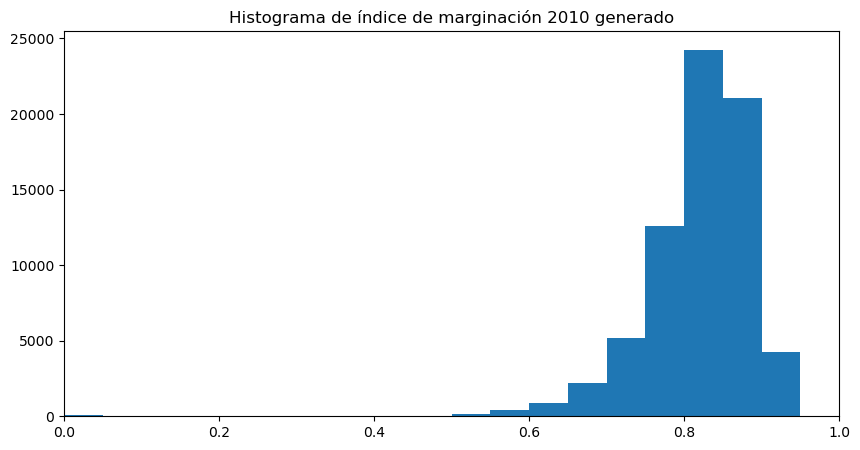

In [40]:
#Histograma
fig, ax = plt.subplots( figsize=(10, 5))
ax.hist(agrupa2010['imn_2010'], bins=20)
ax.set_xlim(0, 1)
ax.set_title('Histograma de índice de marginación 2010 generado')

In [41]:
#Guardar tabla 2010
agrupa2010.to_csv('C:/Users/claud/Documents/GitHub/proyecto_simi/data/indice_marg_2010_construido.csv',index=False)

In [42]:
#Guardar tabla 2020
agrupa.to_csv('C:/Users/claud/Documents/GitHub/proyecto_simi/data/indice_marg_2020_construido.csv',index=False)